In [50]:
# 7_model_validation.ipynb  — compare models on merchant classification
# (uses OCR output at: outputs/ocr/structured_transactions.csv)

import os, re, warnings, numpy as np, pandas as pd
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# project paths
ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATHS = [
    ROOT / "outputs" / "ocr" / "structured_transactions.csv",
    ROOT / "outputs" / "structured_transactions.csv",          # fallback if you kept earlier layout
]
OUT_DIR = ROOT / "outputs" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# pick the first existing CSV
for p in CSV_PATHS:
    if p.exists():
        DATA_CSV = p
        break
else:
    raise FileNotFoundError("Could not find structured_transactions.csv in outputs/ocr/ or outputs/")
print("Using data:", DATA_CSV)


Using data: C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\ocr\structured_transactions.csv


In [51]:
# load
df = pd.read_csv(DATA_CSV)

# expected columns: date, description, debit, credit, balance, source_image
expected = {"description", "debit", "credit"}
missing = expected - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}. Make sure you ran the OCR step.")

# coerce types
df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
for col in ["debit", "credit", "balance"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# keep only rows where at least one of debit/credit exists
df = df[(df["debit"].notna()) | (df["credit"].notna())].copy()

# unify amount (positive) and a sign feature
df["amount"] = df[["debit", "credit"]].max(axis=1, skipna=True)
df["is_credit"] = (df["credit"].fillna(0) > 0).astype(int)

# description cleanup (light)
def clean_text(s: str) -> str:
    if not isinstance(s, str): 
        return ""
    s = s.strip()
    # normalize whitespace, drop long chains of digits to reduce noise
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\d{6,}", " ", s)
    return s

df["description"] = df["description"].fillna("").map(clean_text)

print("Rows after cleaning:", len(df))
df.head(5)


Rows after cleaning: 191


,date,description,debit,credit,balance,source_image,amount,is_credit
0,2023-08-08,OO ESSN ot,NaN,350.0,10804.33,2023_August_Statement (6)_page_2_table_1.png,350.0,1
1,2023-08-09,VANTAGE TOYOTA CD 0523,288.0,NaN,10516.33,2023_August_Statement (6)_page_2_table_1.png,288.0,0
2,2023-08-10,HMRC E VAT,960.0,NaN,9556.33,2023_August_Statement (6)_page_2_table_1.png,960.0,0
3,2023-08-10,ee NSE,NaN,832.0,10388.33,2023_August_Statement (6)_page_2_table_1.png,832.0,1
4,2023-08-10,$Oo RADIO,500.0,NaN,9888.33,2023_August_Statement (6)_page_2_table_1.png,500.0,0


In [52]:
def normalize_desc(s: str) -> str:
    """Uppercase; keep letters/digits/space; use first token as merchant guess."""
    if not isinstance(s, str): return ""
    s = s.upper()
    s = re.sub(r"[^A-Z0-9 ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["merchant_raw"] = df["description"].map(normalize_desc).str.split().str[0].fillna("")

TOP_N = 10
top_merchants = df["merchant_raw"].value_counts().head(TOP_N).index
df["merchant"] = df["merchant_raw"].where(df["merchant_raw"].isin(top_merchants), "OTHER")

print("Top merchants kept:", list(top_merchants))
print("\nClass distribution:")
print(df["merchant"].value_counts())


Top merchants kept: ['OE', 'EBAY', 'OO', 'A', 'EE', 'OT', 'VANTAGE', 'SBAY', 'NO', 'RIGHTWAY']

Class distribution:
merchant
OTHER       118
OE           16
EBAY         15
OO            8
A             7
VANTAGE       5
EE            5
OT            5
NO            4
SBAY          4
RIGHTWAY      4
Name: count, dtype: int64


In [53]:
# numeric helper features
df["day"] = df["date"].dt.day.fillna(0).astype(int)

text_col = "description"
num_cols  = ["amount", "is_credit", "day"]
target    = "merchant"

# vectorizer
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2), lowercase=True)

preprocess = ColumnTransformer(
    transformers=[
        ("text", tfidf, text_col),
        ("num",  StandardScaler(with_mean=False), num_cols)  # with_mean=False for sparse compatibility
    ],
    remainder="drop",
    sparse_threshold=0.3
)

X = df[[text_col] + num_cols].copy()
y = df[target].copy()
classes = sorted(y.unique().tolist())

print("X shape (raw):", X.shape, "| classes:", len(classes))


X shape (raw): (191, 4) | classes: 11


         LogReg: acc = 0.749 ± 0.021
      LinearSVC: acc = 0.916 ± 0.067
   RandomForest: acc = 0.864 ± 0.034
GradientBoosting: acc = 0.927 ± 0.029


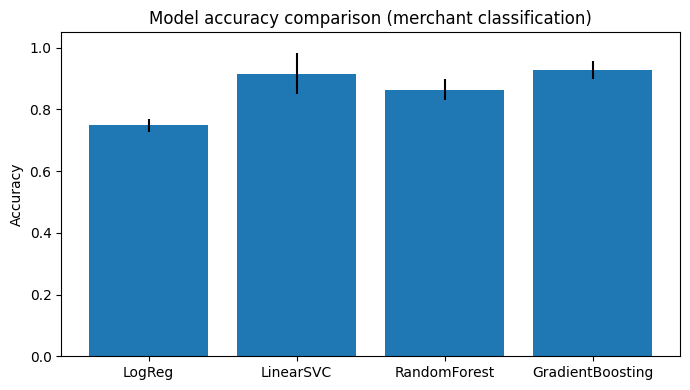

In [54]:
# models to compare
models = {
    "LogReg": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=200, n_jobs=None))
    ]),
    "LinearSVC": Pipeline([
        ("prep", preprocess),
        ("clf", LinearSVC())
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    "GradientBoosting": Pipeline([
        ("prep", preprocess),
        ("clf", GradientBoostingClassifier(random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = {}

for name, pipe in models.items():
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    scores[name] = (acc.mean(), acc.std())
    print(f"{name:>15}: acc = {acc.mean():.3f} ± {acc.std():.3f}")

# bar plot
plt.figure(figsize=(7,4))
names = list(scores.keys())
means = [scores[n][0] for n in names]
stds  = [scores[n][1] for n in names]
plt.bar(names, means, yerr=stds)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Model accuracy comparison (merchant classification)")
plt.tight_layout()
plt.savefig(OUT_DIR / "model_accuracy_comparison.png", dpi=160)
plt.show()

pd.DataFrame(
    {"model": names, "acc_mean": means, "acc_std": stds}
).to_csv(OUT_DIR / "model_accuracy_summary.csv", index=False)


Best model: GradientBoosting


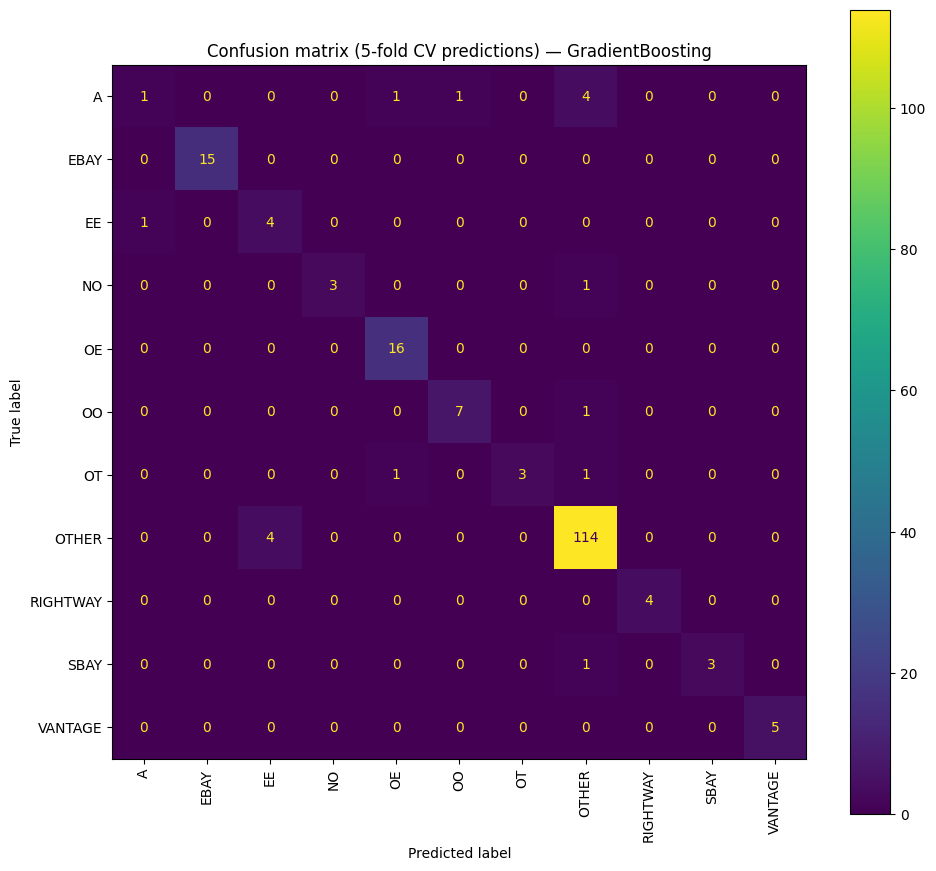


Classification report (macro averages most meaningful with class imbalance):

              precision    recall  f1-score   support

           A      0.500     0.143     0.222         7
        EBAY      1.000     1.000     1.000        15
          EE      0.500     0.800     0.615         5
          NO      1.000     0.750     0.857         4
          OE      0.889     1.000     0.941        16
          OO      0.875     0.875     0.875         8
          OT      1.000     0.600     0.750         5
       OTHER      0.934     0.966     0.950       118
    RIGHTWAY      1.000     1.000     1.000         4
        SBAY      1.000     0.750     0.857         4
     VANTAGE      1.000     1.000     1.000         5

    accuracy                          0.916       191
   macro avg      0.882     0.808     0.824       191
weighted avg      0.914     0.916     0.908       191



In [55]:
best_name = max(scores.items(), key=lambda kv: kv[1][0])[0]
print("Best model:", best_name)

best_model = models["LinearSVC"]  # (you can also use the name from best_name)

# cross-validated predictions (for confusion matrix)
y_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=y, y_pred=y_pred, labels=classes, ax=ax, cmap="viridis", xticks_rotation=90,
    colorbar=True
)
ax.set_title("Confusion matrix (5-fold CV predictions) — " + best_name)
plt.tight_layout()
plt.savefig(OUT_DIR / f"confusion_matrix_{best_name}.png", dpi=160)
plt.show()

print("\nClassification report (macro averages most meaningful with class imbalance):\n")
print(classification_report(y, y_pred, digits=3))


In [56]:
# OPTIONAL: fit on full data and save with joblib for downstream use
from joblib import dump

final_pipe = best_model.fit(X, y)
dump(final_pipe, OUT_DIR / f"merchant_classifier_{best_name}.joblib")
print("Saved:", OUT_DIR / f"merchant_classifier_{best_name}.joblib")


Saved: C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\eda\merchant_classifier_GradientBoosting.joblib
